In [1]:
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chempiler import ChempilerTrajectory, diffusive_window
from chempiler.vanhove import van_hove
from chempiler import van_hove_heatmap
from chempiler.vdos import read_vdos, smooth
from chempiler.state_engine import atom_hop

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset)
})

dt            = 0.5   # fs
dump_interval = 10
dt_per_frame  = dt * dump_interval * 1e-3  # ps per frame

LOGFILE_ANION   = '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/39_water_OH.log'
LOGFILE_RADICAL = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.log'
LOGFILE_WATER   = '../data/MACE-POLAR-1-M/40_water/40_water_polar.log'

TRAJFILE_ANION   = '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/39_water_OH.traj'
TRAJFILE_RADICAL = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.traj'
TRAJFILE_WATER   = '../data/MACE-POLAR-1-M/40_water/40_water_polar.traj'

In [2]:
traj_anion = ChempilerTrajectory(TRAJFILE_ANION, mode='molecular', covalent_scale=0.8)
traj_anion.build(cache_file='tests/OH_dyn_cache.h5', persistence=3)

traj_radical = ChempilerTrajectory(TRAJFILE_RADICAL, mode='molecular', covalent_scale=0.8)
traj_radical.build(cache_file='tests/OH_rad_dyn_cache.h5', persistence=3)

traj_water = ChempilerTrajectory(TRAJFILE_WATER, mode='molecular', covalent_scale=0.8)
traj_water.build(cache_file='tests/40_water_cache.h5', persistence=3)

[Chempiler] loaded cache → tests/OH_dyn_cache.h5
[Chempiler] persistence=3: corrected 209 frames
[Chempiler] loaded cache → tests/OH_rad_dyn_cache.h5
[Chempiler] loaded cache → tests/40_water_cache.h5


In [ ]:
plts = {
    'O$_h \\cdots$O$_w$': ({"HO": "O"}, {"H2O": "O"}),
    'O$_h \\cdots$H$_w$': ({"HO": "O"}, {"H2O": "H"}),
    'H$_h \\cdots$O$_w$': ({"HO": "H"}, {"H2O": "O"}),
}

fig, axs = plt.subplots(1,3, figsize=(3*6, 5), sharey=True)
for ax, (label, pair) in zip(axs, plts.items()):
    CTR, TGT = pair
    r_ion, g_ion = traj_anion.rdf(center=CTR, target=TGT, dr=0.05)
    r_rad, g_rad = traj_radical.rdf(center=CTR, target=TGT, dr=0.05)
    r_w, g_w = traj_water.rdf(center=TGT, target=TGT, dr=0.05)
    

    ax.plot(r_ion,g_ion, color=cset.blue, label='OH$^-$ + H$_2$O')
    ax.plot(r_rad,g_rad, color=cset.red, label='OH$^\circ$ + H$_2$O')
    ax.plot(r_w,g_w, color='0.5', ls=':', label='H$_2$O')
    ax.set_title(label)
    ax.set_xlabel('r /Å')

axs[0].set_ylabel('$g(r)$')
axs[0].legend(loc='upper left')

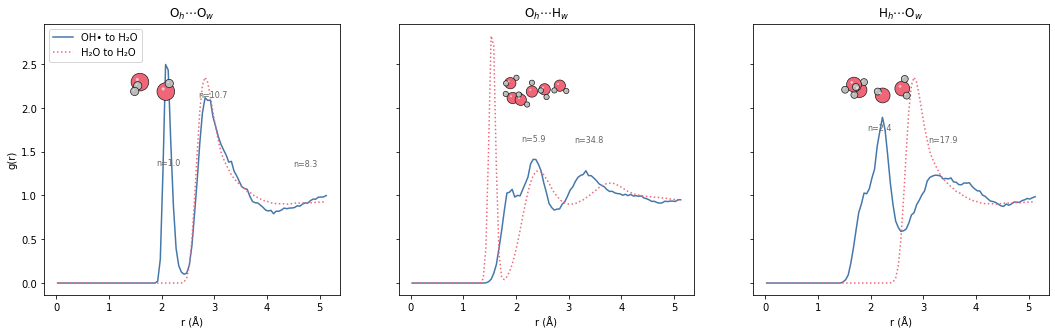

In [5]:
import json
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from chempiler import plot_rdf


RDF_DIR = Path('results/oh_comparison/rdf_data')
ENV_DIR = Path('results/oh_comparison/envs')

def pair_key(pair):
    CTR, TGT = pair
    return '{}{}_{}{}'.format(
        list(CTR.keys())[0], list(CTR.values())[0],
        list(TGT.keys())[0], list(TGT.values())[0],
    )

fig, axs = plt.subplots(1, 3, figsize=(3*6, 5), sharey=True)

for ax, (label, pair) in zip(axs, plts.items()):
    key = pair_key(pair)

    # Load pre-computed RDF
    data = np.loadtxt(RDF_DIR / f'{key}_rdf.csv', delimiter=',', skiprows=1)
    r, g, n, gw = data[:, 0], data[:, 1], data[:, 2], data[:, 3]

    # Load environment manifest (shell index → peak position + xyz path)
    manifest = json.load(open(ENV_DIR / f'{key}_manifest.json'))
    shell0, shell1, *rest = [k for k in manifest if not k.startswith('_')]

    plot_rdf(r, g, ax=ax, label='OH• to H₂O', insets={
        manifest[shell0]['peak']: {'file': manifest[shell0]['file'], 'view':1},
        # manifest[shell1]['peak']: {'file': manifest[shell1]['file']},
    })

    # Per-shell (annular) CN annotations
    dr       = float(r[1] - r[0])
    g_smooth = gaussian_filter1d(g, sigma=0.2 / dr)
    peaks    = manifest['_shells']['peaks']
    cns      = manifest['_shells']['cns']
    ann_cn   = np.diff(np.r_[0, cns])
    for peak_r, cn in zip(peaks, ann_cn):
        peak_g = float(np.interp(peak_r, r, g_smooth))
        ax.text(peak_r, peak_g + 0.4, f'n={cn:.1f}',
                ha='center', va='bottom', fontsize=8, color='0.4')

    ax.plot(r, gw, ':', label='H₂O to H₂O')
    ax.set_title(label)
    ax.set_xlabel('r (Å)')

axs[0].set_ylabel('g(r)')
axs[0].legend(loc='upper left')
